# 1. Import and Hardware Setup

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import matplotlib.pyplot as plt
import numpy as np

!pip install tqdm ipywidgets -q
from tqdm.auto import tqdm

!pip install wandb -q
import wandb

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [19]:
DATA_PATH = './Data'
SAVE_PATH = '.Model'

In [20]:
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

# 2. Hyperparameters

In [21]:
IMG_SIZE = 224
IN_CHANNELS = 3
BATCH_SIZE = 128

EPOCHS = 5
LR = 0.04
NUM_CLS = 101
DROPOUT_RATE = 0.5

SEED = 42

# 3. Training Data Preparation

In [22]:
stats = ((0.545, 0.443, 0.344), (0.269, 0.271, 0.276))

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

In [23]:
import os
import random

def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.random.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

set_seed(SEED)

In [24]:
# Download train data without transform
dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

# Split the data using generator
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
split_generator = torch.Generator().manual_seed(SEED)

train_subset_temp, val_subset_temp = random_split(
    dummy_data, [train_size, val_size], generator=split_generator
)
train_idx = train_subset_temp.indices
val_idx = val_subset_temp.indices

# Create two separate dataset objects so they don't share referencing issues when pickling
train_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=train_transform
)
val_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=test_transform
)

# Create Subsets using the indices
train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(val_dataset, val_idx)

# Download the test data
test_data = datasets.Food101(
    root=DATA_PATH, split="test", download=True, transform=test_transform
)

In [25]:
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)


train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

# 4. Model Architecture

<table>
  <tr>
    <td><img src="VGG16.png"></td>
    <td><img src="VGG16_2.png"></td>
  </tr>
</table>

In [ ]:
class VGG16(nn.Module):
    def __init__(self, in_channels, num_cls, dropout_rate):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            # ---------- 1. Block ---------- 

            # Conv (224x224x3) -> (224x224x64)
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # Conv (224x224x64) -> (224x224x64)
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # Pool (224x224x64) -> (112x112x64)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # ---------- 2. Block ---------- 

            # Conv (112x112x64) -> (112x112x128)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # Conv (112x112x128) - (112x112x128)
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # Pool (112x112x128) -> (56x56x128)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # ---------- 3. Block ---------- 
            # (56x56x128) -> (56x56x256)
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # (56x56x256) -> (56x56x256)
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # (56x56x256) -> (56x56x256)
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # (56x56x256) -> (28x28x256)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # ---------- 4. Block ----------
            # (28x28x256) -> (28x28x512) 
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # (28x28x512) -> (28x28x512)
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # (28x28x512) -> (28x28x512)
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # (28x28x512) -> (14x14x512)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # ---------- 5. Block ----------
            # (14x14x512) -> (14x14x512)
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # (14x14x512) -> (14x14x512)
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # (14x14x512) -> (14x14x512)
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            # (14x14x512) -> (7x7x512)
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(7*7*512, 4096),
            nn.ReLU(),

            nn.Dropout(dropout_rate),
            nn.Linear(4096, 4096),
            nn.ReLU(),

            nn.Linear(4096, num_cls)
        )
        
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # VGG Paper used random initialization with zero mean and 0.01 variance
                # Later they found Xavier/Kaiming works better for deep networks
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)

        return logits

model = VGG16(IN_CHANNELS, NUM_CLS, DROPOUT_RATE).to(device)

print(f"Total paramters {sum(p.numel() for p in model.parameters()/1e6):.2f}M")

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# 5. Training Preparation

In [27]:
class EarlyStopping:
    def __init__(self, patience=10, delta = 0, verbose = False, save_path='best_model.pth', trace_func=print):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path
        self.trace_func = trace_func

        self.best_score = None
        self.earlystop = False
        self.counter = 0

    def __call__(self, val_loss, model):

        # The first epoch
        if self.best_score is None:
            self.best_score = val_loss
            self.save_checkpoint(val_loss, model)

        # The loss didnt reduce much as expect or increased
        elif val_loss >= self.best_score - self.delta:
            self.counter += 1
            self.trace_func(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if (self.counter >= self.patience):
                self.earlystop = True
        
        # The loss reduced properly
        else:
            self.best_score = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        
        if self.verbose:
            self.trace_func("Best Model saving ...")
        torch.save(model.state_dict(), self.save_path)

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience= 5, factor=0.1)

# Using GradScaler to prevent Gradient Underflow by using FP16
scaler = torch.amp.GradScaler(device)

In [29]:
def train(model, loader, criterion, optimizer, scaler):
    # Set the Model in Training Mode
    model.train()

    loop = tqdm(loader, desc="Training", leave=False)
    
    # Initialize accumulators on device to avoid CPU-GPU sync
    train_loss = torch.tensor(0.0, device=device)
    train_acc = torch.tensor(0.0, device=device)

    for x, y in loop:
        # Move data to device
        x, y = x.to(device), y.to(device)

        # Clear the Gradient of last batch
        optimizer.zero_grad(set_to_none=True)

        # Get prediction & loss with Automatic Mixed Precision (AMP)
        with torch.amp.autocast(device_type=device.type):
            out = model(x)
            loss = criterion(out, y)

        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()

        # Scale down the Gradients before clipping
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Check if the gradients are valid after Unscaling
        scaler.step(optimizer)

        # Adjust the Scale Factor for the next batch
        scaler.update()

        # Sum up the loss and accuracy using local tensor accumulator
        train_loss += loss.detach() * x.size(0)
        train_acc += (out.argmax(1) == y).sum()

    # Move to CPU only at the end
    return train_loss.item() / len(loader.dataset), train_acc.item() / len(loader.dataset)

In [30]:
def validate(model, loader, criterion):
    model.eval()
    loop = tqdm(loader, desc="Validation", leave=False)
    val_loss, val_acc = 0, 0

    for x, y in loop:
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            out = model(x)
            loss = criterion(out, y)

        val_loss += loss.item() * x.size(0)
        val_acc += (out.argmax(1) == y).sum().item()
    
    return val_loss / len(loader.dataset), val_acc / len(loader.dataset)

In [31]:
def test(model, loader):
    model.eval()
    test_acc = 0
    loop = tqdm(loader, desc="Testing", leave=False)
    for x, y in loop:
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            out = model(x)
        test_acc += (out.argmax(1) == y).sum().item()

    return test_acc / len(loader.dataset)

# 6. Training Loop

In [ ]:
wandb.init(
    project="VGG",
    config={
        "Architecture": "VGG16",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "image_size": IMG_SIZE
    }
)

train_accuracies, val_accuracies = [], []
train_losses, val_losses = [], []

early_stopping = EarlyStopping(patience=10)

for epoch in range(EPOCHS):
    
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_acc = validate(model,  val_loader, criterion)
    scheduler.step(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    wandb.log({
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "lr": optimizer.param_groups[0]['lr']
    })

    print(f"Epoch: {epoch+1}/{EPOCHS} - train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, " + 
           f"train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")

    early_stopping(val_loss, model)

    if early_stopping.earlystop:
        print("Early Stopping")
        break

best_model = model.module if hasattr(model, 'module') else model
best_model.load_state_dict(torch.load('best_checkpoint.pth', map_location=device))
test_acc = test(model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")
wandb.log(f"Test accuracy: {test_acc:.4f}")

wandb.finish()

Training:   0%|          | 0/474 [00:00<?, ?it/s]

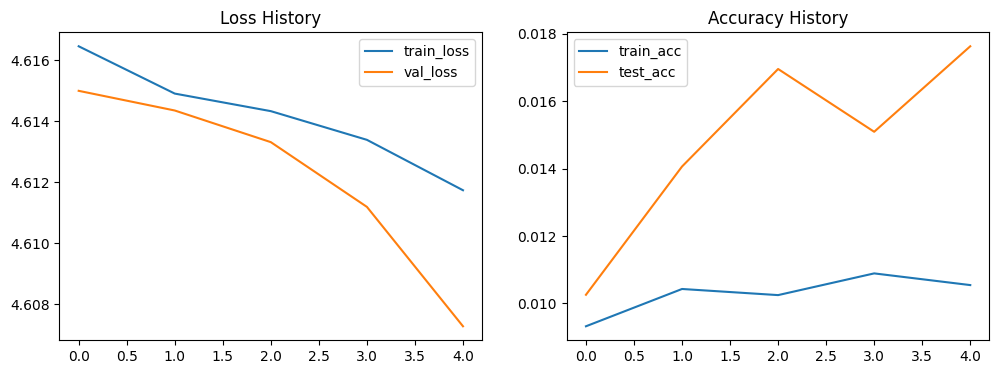

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label = "train_loss")
plt.plot(val_losses, label = "val_loss")
plt.title("Loss History")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label = "train_acc")
plt.plot(val_accuracies, label = "test_acc")
plt.title("Accuracy History")
plt.legend()

# 7. GradCAM

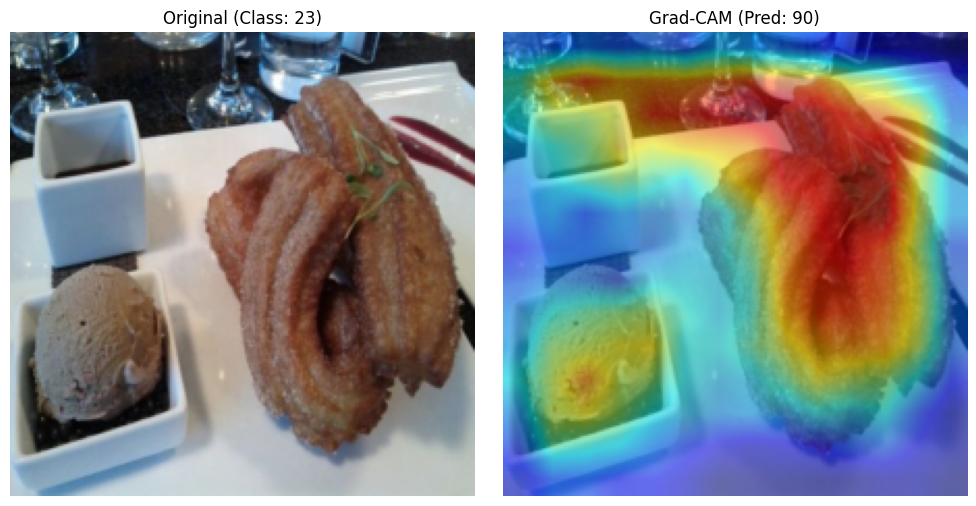

In [ ]:
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import random

# Pick the last Conv Layer to setup the GradCAM
if isinstance(model, nn.DataParallel):
    target_layers = [model.module.feature_extractor[-3]]
else:
    target_layers = [model.feature_extractor[-3]]
cam = GradCAM(model=model, target_layers=target_layers)

# Pick a random image form the test set
imgs, labels = next(iter(test_loader))
index = random.randint(0, len(imgs) - 1)
input_tensor = imgs[index].unsqueeze(0).to(device)
label = labels[index].item()

# Generate the Grad-CAM heatmap
grayscale_cam = cam(input_tensor=input_tensor, targets=None)
grayscale_cam = grayscale_cam[0, :]

# Prepare the image for Visualization
# create a 1D Tensor from the tuple of per-channel means/std
# and reshape it to (3, 1, 1) because imgs[index] has (3, H, W)
mean = torch.tensor(stats[0]).view(3, 1, 1)
std = torch.tensor(stats[1]).view(3, 1, 1)
rgb_img = imgs[index] * std + mean # Denormalize
rgb_img = rgb_img.permute(1, 2, 0).numpy()
rgb_img = np.clip(rgb_img, 0, 1)

# Overlay the heatmap on the image
visual = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Get the Prediction
model.eval()
with torch.no_grad():
    out = model(input_tensor)
    pred = out.argmax(1).item()

# 7. Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"Original (Class: {label})")
plt.imshow(rgb_img)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title(f"Grad-CAM (Pred: {pred})")
plt.imshow(visual)
plt.axis('off')
plt.tight_layout()
plt.show()